In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from google.colab import files

In [ ]:
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])
df.head()

Saving Food_wastage.csv to Food_wastage.csv


,country,region,year,population,income_group,gdp,gdp_per_capita,food_type,total_waste,food economic_loss,household_waste,total_household_waste,total_commercial_waste,avg_waste_per_capita,economic_loss_waste_per_capita
0,Australia,Oceania,2019,25203198,High income,1390,55151.73114,Fruits & Vegetables,19268.63,18686.68,53.64,10335.693130,8932.936868,72.69,741.440828
1,USA,North America,2024,340110988,High income,29000,85266.28372,Beverages,22924.85,22406.24,45.43,10414.759350,12510.090650,89.59,65.879201
2,USA,North America,2024,340110988,High income,29000,85266.28372,Prepared Food,35924.32,30004.90,42.27,15185.210060,20739.109940,192.56,88.220907
3,Australia,Oceania,2020,25499884,High income,1330,52157.10001,Fruits & Vegetables,1322.82,1394.01,30.63,405.179766,917.640234,88.85,54.667308
4,Australia,Oceania,2020,25499884,High income,1330,52157.10001,Beverages,45243.85,37828.94,50.34,22775.754090,22468.095910,47.21,1483.494592


In [ ]:
print("Số dòng và cột:", df.shape)
print("Giá trị thiếu:", df.isnull().sum().sum())
print("Số dòng trùng:", df.duplicated().sum())
print(df.describe(include='all'))
print("Các năm trong dataset:", sorted(df['year'].unique()))
print("Các quốc gia:", df['country'].unique())

Số dòng và cột: (5000, 15)
Giá trị thiếu: 0
Số dòng trùng: 0
        country  region         year    population income_group           gdp  \
count      5000    5000  5000.000000  5.000000e+03         5000   5000.000000   
unique       20       7          NaN           NaN            3           NaN   
top     Germany  Europe          NaN           NaN  High income           NaN   
freq        287    1788          NaN           NaN         2752           NaN   
mean        NaN     NaN  2021.015600  2.409473e+08          NaN   3942.448600   
std         NaN     NaN     1.999239  4.062563e+08          NaN   5874.873909   
min         NaN     NaN  2018.000000  2.499237e+07          NaN    335.000000   
25%         NaN     NaN  2019.000000  5.159537e+07          NaN   1290.000000   
50%         NaN     NaN  2021.000000  8.290578e+07          NaN   1890.000000   
75%         NaN     NaN  2023.000000  2.092883e+08          NaN   3400.000000   
max         NaN     NaN  2024.000000  1.450936e+

In [ ]:
# ===========================
# 3. Tiền xử lý dữ liệu
# ===========================
# Label Encoding cho categorical
le_region = LabelEncoder()
le_income = LabelEncoder()
le_food = LabelEncoder()

df['region'] = le_region.fit_transform(df['region'])
df['income_group'] = le_income.fit_transform(df['income_group'])
df['food_type'] = le_food.fit_transform(df['food_type'])

# Chọn cột numeric để scale
numeric_cols = ['year','population','gdp','gdp_per_capita','total_waste',
                'household_waste','total_household_waste','total_commercial_waste',
                'avg_waste_per_capita','economic_loss_waste_per_capita']

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [ ]:
# ===========================
# 4. X và Y
# ===========================
X = df.drop(columns=['food economic_loss','country'])
y = df['food economic_loss']

# Chia train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# ===========================
# 5. Train mô hình
# ===========================
# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# XGBoost
xgb = XGBRegressor(n_estimators=200, random_state=42)
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# ===========================
# 6. Đánh giá mô hình
# ===========================
def eval_reg(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

print("Random Forest:", eval_reg(y_test, y_pred_rf))
print("XGBoost:", eval_reg(y_test, y_pred_xgb))

Random Forest: {'RMSE': np.float64(2616.1345697218358), 'MAE': 1937.830679749999, 'R2': 0.9702139976809742}
XGBoost: {'RMSE': np.float64(1553.5247142332182), 'MAE': 1062.0260792700196, 'R2': 0.9894966365686836}


In [ ]:

future_years = [int(df['year'].max()) + i for i in range(1,6)]
countries = df['country'].unique()

rows = []
for c in countries:
    last = df[df['country']==c].sort_values('year').iloc[-1]
    pop_growth = 0.01
    gdp_growth = 0.03
    waste_growth = 0.02
    for i, y in enumerate(future_years):
        r = last.copy()
        r['year'] = y
        r['population'] *= (1 + pop_growth)**(i+1)
        r['gdp'] *= (1 + gdp_growth)**(i+1)
        r['gdp_per_capita'] *= (1 + gdp_growth)**(i+1)
        r['total_waste'] *= (1 + waste_growth)**(i+1)
        r['household_waste'] *= (1 + waste_growth)**(i+1)
        r['total_household_waste'] *= (1 + waste_growth)**(i+1)
        r['total_commercial_waste'] *= (1 + waste_growth)**(i+1)
        r['avg_waste_per_capita'] *= (1 + waste_growth)**(i+1)
        r['economic_loss_waste_per_capita'] *= (1 + waste_growth)**(i+1)
        rows.append(r)

df_future = pd.DataFrame(rows)

df_future['region'] = le_region.transform(df_future['region'])
df_future['income_group'] = le_income.transform(df_future['income_group'])
df_future['food_type'] = le_food.transform(df_future['food_type'])
df_future[numeric_cols] = scaler.transform(df_future[numeric_cols])
X_future = df_future.drop(columns=['food economic_loss','country'])
df_future['pred_rf'] = rf.predict(X_future)
df_future['pred_xgb'] = xgb.predict(X_future)


/tmp/ipython-input-4247810650.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_rf.values, y=top10_rf.index, palette="Blues_r")


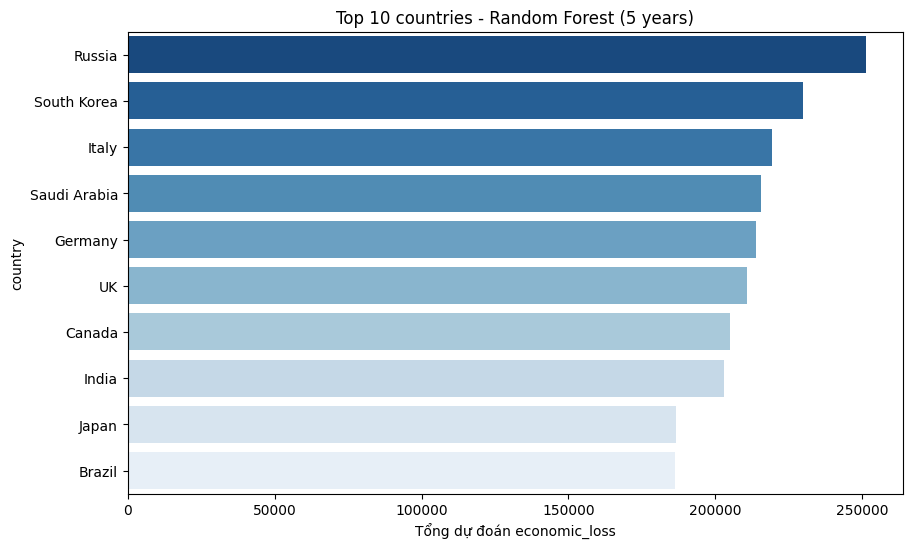

/tmp/ipython-input-4247810650.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_xgb.values, y=top10_xgb.index, palette="Greens_r")


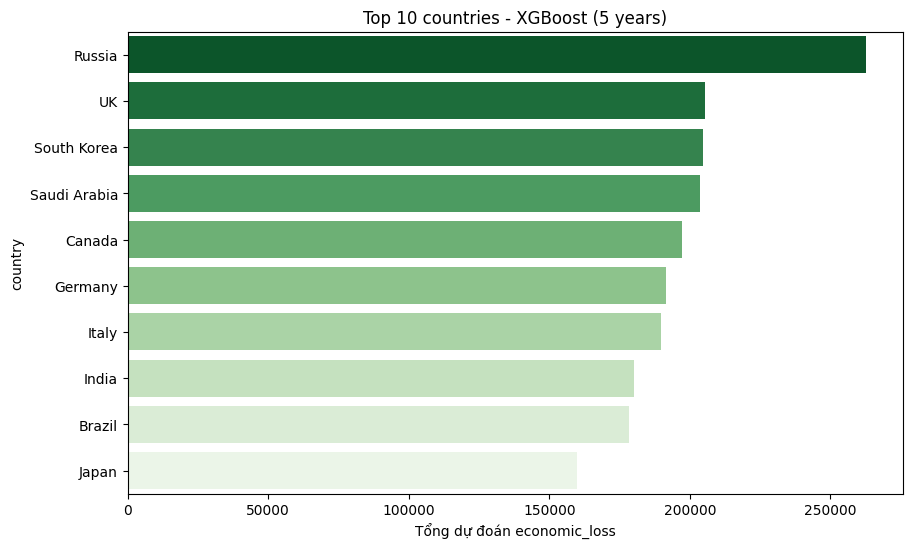

In [ ]:
top10_rf = df_future.groupby('country')['pred_rf'].sum().sort_values(ascending=False).head(10)
top10_xgb = df_future.groupby('country')['pred_xgb'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top10_rf.values, y=top10_rf.index, palette="Blues_r")
plt.title("Top 10 countries - Random Forest (5 years)")
plt.xlabel("Tổng dự đoán economic_loss")
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(x=top10_xgb.values, y=top10_xgb.index, palette="Greens_r")
plt.title("Top 10 countries - XGBoost (5 years)")
plt.xlabel("Tổng dự đoán economic_loss")
plt.show()

In [ ]:

top10_rf = df_future.groupby('country')['pred_rf'].sum().sort_values(ascending=False).head(10)
print("Top 10 quốc gia dự đoán thiệt hại kinh tế nặng nhất (Random Forest):")
print(top10_rf)
print("\n")
top10_xgb = df_future.groupby('country')['pred_xgb'].sum().sort_values(ascending=False).head(10)
print("Top 10 quốc gia dự đoán thiệt hại kinh tế nặng nhất (XGBoost):")
print(top10_xgb)


Top 10 quốc gia dự đoán thiệt hại kinh tế nặng nhất (Random Forest):
country
Russia          251272.53130
South Korea     229983.32185
Italy           219366.72965
Saudi Arabia    215625.17325
Germany         214021.30290
UK              210716.88110
Canada          204966.50350
India           203105.27485
Japan           186726.10180
Brazil          186198.86220
Name: pred_rf, dtype: float64


Top 10 quốc gia dự đoán thiệt hại kinh tế nặng nhất (XGBoost):
country
Russia          262657.468750
UK              205522.718750
South Korea     204784.281250
Saudi Arabia    203467.609375
Canada          197167.046875
Germany         191507.109375
Italy           189801.718750
India           180110.937500
Brazil          178317.968750
Japan           159826.468750
Name: pred_xgb, dtype: float32
